# CPC353 Natural Language Processing
## Assignment 2: Stock Trend Prediction with News Sentiment
### Part 1b: Data Preparation

This notebook prepares the stock_trend.csv dataset for training, validation, and testing.

## 1. Import Libraries

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

## 2. Load the Dataset

In [45]:
# Load the dataset
df = pd.read_csv(r"stock_trend.csv")

# Display basic information
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\n" + "="*60)
print("First 10 rows of original dataset:")
print("="*60)
df.head(10)

Dataset Shape: (24388, 6)

Column Names: ['Title', 'Time', 'Name', 'Quote', 'Before', 'After']

Data Types:
Title      object
Time       object
Name       object
Quote       int64
Before    float64
After     float64
dtype: object

First 10 rows of original dataset:


,Title,Time,Name,Quote,Before,After
0,100 startups participate in Maxis' Market Acce...,2019-12-12T23:50:12+08:00,MAXIS,6012,5.160,5.110
1,16.89% stake in Subur Tiasa traded off-market,2020-02-20T22:41:12+08:00,SUBUR,6904,0.610,0.610
2,Najib wanted 1MDB's Genting Sanyen deal sped u...,2020-07-16T17:42:30+08:00,GENTING,3182,4.080,4.060
3,"25bps OPR cut likely in 2H20, says Manulife",2020-01-16T17:03:43+08:00,MANULFE,1058,2.420,2.420
4,A 25-month extension on concession pushes Phar...,2019-11-11T10:49:58+08:00,PHARMA,7081,2.620,2.430
5,3.7% of Yong Tai transacted off-market,2019-09-05T19:55:54+08:00,YONGTAI,7066,0.195,0.200
6,"3A, Ruberex, Thriven, Kanger, UniWall",2020-03-04T13:23:15+08:00,KANGER,170,0.125,0.120
7,40% stake in IWH-CREC may cost Ekovest RM1.5b,2020-09-16T10:00:00+08:00,EKOVEST,8877,0.610,0.580
8,4.41% Kronologi Asia shares traded off-market,2020-02-12T23:54:51+08:00,KRONO,176,0.895,0.890
9,4.96% of MMAG traded off market,2019-07-23T22:42:17+08:00,MMAG,34,0.245,0.235


## 3. Calculate Relative Price Change

Calculate the percentage change in stock price:
- Formula: `((After - Before) / Before) * 100`

In [46]:
# Calculate relative price change percentage
df['Price_Change_Percent'] = ((df['After'] - df['Before']) / df['Before']) * 100

print("After calculating Price Change Percentage:")
print("="*60)
print("\nPrice Change Statistics:")
print(df['Price_Change_Percent'].describe())
print("\n" + "="*60)
print("First 10 rows after adding Price_Change_Percent:")
print("="*60)
df[['Title', 'Name', 'Before', 'After', 'Price_Change_Percent']].head(10)

After calculating Price Change Percentage:

Price Change Statistics:
count    24388.000000
mean         0.931280
std          7.650143
min        -54.545455
25%         -1.291006
50%          0.000000
75%          1.980198
max        260.000000
Name: Price_Change_Percent, dtype: float64

First 10 rows after adding Price_Change_Percent:


,Title,Name,Before,After,Price_Change_Percent
0,100 startups participate in Maxis' Market Acce...,MAXIS,5.160,5.110,-0.968992
1,16.89% stake in Subur Tiasa traded off-market,SUBUR,0.610,0.610,0.000000
2,Najib wanted 1MDB's Genting Sanyen deal sped u...,GENTING,4.080,4.060,-0.490196
3,"25bps OPR cut likely in 2H20, says Manulife",MANULFE,2.420,2.420,0.000000
4,A 25-month extension on concession pushes Phar...,PHARMA,2.620,2.430,-7.251908
5,3.7% of Yong Tai transacted off-market,YONGTAI,0.195,0.200,2.564103
6,"3A, Ruberex, Thriven, Kanger, UniWall",KANGER,0.125,0.120,-4.000000
7,40% stake in IWH-CREC may cost Ekovest RM1.5b,EKOVEST,0.610,0.580,-4.918033
8,4.41% Kronologi Asia shares traded off-market,KRONO,0.895,0.890,-0.558659
9,4.96% of MMAG traded off market,MMAG,0.245,0.235,-4.081633


## 4. Assign Trend Labels

Based on the relative price change:
- **Uptrend**: Price change > +10%
- **Downtrend**: Price change < -10%
- **Flat**: Price change between -10% and +10%

In [47]:
# Define function to assign trend label
def assign_trend(change_percent):
    if change_percent > 10:
        return 'uptrend'
    elif change_percent < -10:
        return 'downtrend'
    else:
        return 'flat'

# Apply the function to create Trend column
df['Trend'] = df['Price_Change_Percent'].apply(assign_trend)

print("After assigning Trend labels:")
print("="*60)
print("\nTrend Distribution:")
print(df['Trend'].value_counts())
print("\nTrend Percentage Distribution:")
print(df['Trend'].value_counts(normalize=True) * 100)
print("\n" + "="*60)
print("First 10 rows after adding Trend label:")
print("="*60)
df[['Title', 'Name', 'Before', 'After', 'Price_Change_Percent', 'Trend']].head(10)

After assigning Trend labels:

Trend Distribution:
Trend
flat         22626
uptrend       1232
downtrend      530
Name: count, dtype: int64

Trend Percentage Distribution:
Trend
flat         92.775135
uptrend       5.051665
downtrend     2.173200
Name: proportion, dtype: float64

First 10 rows after adding Trend label:


,Title,Name,Before,After,Price_Change_Percent,Trend
0,100 startups participate in Maxis' Market Acce...,MAXIS,5.160,5.110,-0.968992,flat
1,16.89% stake in Subur Tiasa traded off-market,SUBUR,0.610,0.610,0.000000,flat
2,Najib wanted 1MDB's Genting Sanyen deal sped u...,GENTING,4.080,4.060,-0.490196,flat
3,"25bps OPR cut likely in 2H20, says Manulife",MANULFE,2.420,2.420,0.000000,flat
4,A 25-month extension on concession pushes Phar...,PHARMA,2.620,2.430,-7.251908,flat
5,3.7% of Yong Tai transacted off-market,YONGTAI,0.195,0.200,2.564103,flat
6,"3A, Ruberex, Thriven, Kanger, UniWall",KANGER,0.125,0.120,-4.000000,flat
7,40% stake in IWH-CREC may cost Ekovest RM1.5b,EKOVEST,0.610,0.580,-4.918033,flat
8,4.41% Kronologi Asia shares traded off-market,KRONO,0.895,0.890,-0.558659,flat
9,4.96% of MMAG traded off market,MMAG,0.245,0.235,-4.081633,flat


## 5. Prepare Features and Labels

In [48]:
# Extract text (Title) as features and Trend as labels
X = df['Title'].values  # News headlines as input
y = df['Trend'].values  # Trend labels

print("Features and Labels prepared:")
print("="*60)
print(f"Total samples: {len(X)}")
print(f"Feature shape: {X.shape}")
print(f"Label shape: {y.shape}")
print("\n" + "="*60)
print("First 10 samples (Title, Trend):")
print("="*60)
for i in range(10):
    print(f"{i+1}. Title: {X[i][:60]}...")
    print(f"   Trend: {y[i]}")
    print()

Features and Labels prepared:
Total samples: 24388
Feature shape: (24388,)
Label shape: (24388,)

First 10 samples (Title, Trend):
1. Title: 100 startups participate in Maxis' Market Access Day...
   Trend: flat

2. Title: 16.89% stake in Subur Tiasa traded off-market...
   Trend: flat

3. Title: Najib wanted 1MDB's Genting Sanyen deal sped up on fears car...
   Trend: flat

4. Title: 25bps OPR cut likely in 2H20, says Manulife...
   Trend: flat

5. Title: A 25-month extension on concession pushes Pharmaniaga up by ...
   Trend: flat

6. Title: 3.7% of Yong Tai transacted off-market...
   Trend: flat

7. Title: 3A, Ruberex, Thriven, Kanger, UniWall...
   Trend: flat

8. Title: 40% stake in IWH-CREC may cost Ekovest RM1.5b...
   Trend: flat

9. Title: 4.41% Kronologi Asia shares traded off-market...
   Trend: flat

10. Title: 4.96% of MMAG traded off market...
   Trend: flat



## 6. Split Data into Train, Validation, and Test Sets

Split ratio:
- **Training**: 70%
- **Validation**: 20%
- **Test**: 10%

In [49]:
# First split: 70% train, 30% temp (which will be split into validation and test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.30, 
    random_state=42, 
    stratify=y  # Maintain class distribution
)

# Second split: Split the temp into validation (20/30 = 66.67%) and test (10/30 = 33.33%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.333,  # 10% of total (0.30 * 0.333 ≈ 0.10)
    random_state=42,
    stratify=y_temp  # Maintain class distribution
)

print("After splitting data into Train, Validation, and Test sets:")
print("="*60)
print(f"\nTotal samples: {len(X)}")
print(f"Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation samples: {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")

After splitting data into Train, Validation, and Test sets:

Total samples: 24388
Training samples: 17071 (70.0%)
Validation samples: 4880 (20.0%)
Test samples: 2437 (10.0%)


In [50]:
# Display class distribution in each set
print("\nClass distribution in each set:")
print("="*60)

print("\nTraining Set Distribution:")
train_dist = pd.Series(y_train).value_counts()
print(train_dist)

print("\nValidation Set Distribution:")
val_dist = pd.Series(y_val).value_counts()
print(val_dist)

print("\nTest Set Distribution:")
test_dist = pd.Series(y_test).value_counts()
print(test_dist)


Class distribution in each set:

Training Set Distribution:
flat         15838
uptrend        862
downtrend      371
Name: count, dtype: int64

Validation Set Distribution:
flat         4527
uptrend       247
downtrend     106
Name: count, dtype: int64

Test Set Distribution:
flat         2261
uptrend       123
downtrend      53
Name: count, dtype: int64


## 7. Display First 10 Rows of Each Set

In [51]:
print("\n" + "="*60)
print("TRAINING SET - First 10 rows:")
print("="*60)
train_df = pd.DataFrame({'Title': X_train[:10], 'Trend': y_train[:10]})
train_df.index = range(1, 11)
print(train_df.to_string())


TRAINING SET - First 10 rows:
                                                                                                    Title Trend
1                                 UEM Sunrise 2Q net profit up 73% on higher property development revenue  flat
2                                                           Myanmar ops to boost Daibochi’s FY18 earnings  flat
3                         Public Bank, Hong Leong Bank the most defensive against credit risks — CGS-CIMB  flat
4                                              Asia Bioenergy sells entire stake in T7 Global for RM3.65m  flat
5                                                Power Root may rebound further, says RHB Retail Research  flat
6   BAT Malaysia, Sapura Energy, TNB, Texchem, Permaju, KAB, Yi-Lai, Supermax, Ralco, VS Industry and NWP  flat
7                                              IRB claims RM182.8m in income taxes from Magnum subsidiary  flat
8                                              CGS-CIMB Research lowers t

In [52]:
print("\n" + "="*60)
print("VALIDATION SET - First 10 rows:")
print("="*60)
val_df = pd.DataFrame({'Title': X_val[:10], 'Trend': y_val[:10]})
val_df.index = range(1, 11)
print(val_df.to_string())


VALIDATION SET - First 10 rows:
                                                                                     Title Trend
1                                   Supercomnet may trend higher, says RHB Retail Research  flat
2          Citrine Hub serviced residences at Sunway Iskandar to be handed over in October  flat
3   Boustead Plantations' 1Q net profit slumps 82% to RM5.26m, declares 2.50 sen dividend   flat
4                    Daibochi, Pinehill, Ancom Bhd, MCT, Minho, SHL, Eden, Public Packages  flat
5            Focus Dynamics may consolidate with positive bias, says AmInvestment Research  flat
6                     George Kent unaware of any intention by Tan Kay Hock to divest stake  flat
7                           AssetsCo will raise George Kent’s profile in rail system scene  flat
8                        CIMB Research downgrades Berjaya Sports Toto, target price RM2.62  flat
9                                CIMB Research upgrades KPJ, raises target price to RM1.10  fl

In [53]:
print("\n" + "="*60)
print("TEST SET - First 10 rows:")
print("="*60)
test_df = pd.DataFrame({'Title': X_test[:10], 'Trend': y_test[:10]})
test_df.index = range(1, 11)
print(test_df.to_string())


TEST SET - First 10 rows:
                                                                                                                    Title    Trend
1                                                              Eco World International completes stage one of UK land buy     flat
2                                                    Property market to recover in coming years, says Sime Darby Property     flat
3                                                       GHL Systems 4Q net profit up 11.5% as overseas contribution rises     flat
4   AZRB, Diversified Gateway, Formosa Prosonic, Hiap Teck, Luster, OKA, Pantech, SHH, Tasco, United U-Li, LBI, Tiong Nam     flat
5                                                  Messrs CAS Malaysia resigns as external auditor of Key ASIC and UCrest     flat
6                                                                                     Public Bank 3Q net profit at RM1.4b     flat
7                                                  Luste

## 8. Encode Labels for Model Training

In [54]:
# Create label encoding mapping
label_mapping = {'downtrend': 0, 'flat': 1, 'uptrend': 2}
reverse_mapping = {0: 'downtrend', 1: 'flat', 2: 'uptrend'}

# Encode labels
y_train_encoded = np.array([label_mapping[label] for label in y_train])
y_val_encoded = np.array([label_mapping[label] for label in y_val])
y_test_encoded = np.array([label_mapping[label] for label in y_test])

print("After encoding labels:")
print("="*60)
print("\nLabel Mapping:")
for label, code in label_mapping.items():
    print(f"  {label}: {code}")
print("\n" + "="*60)
print("Encoded Training Labels - First 10:")
print("="*60)
for i in range(10):
    print(f"{i+1}. Original: {y_train[i]:10s} -> Encoded: {y_train_encoded[i]}")

After encoding labels:

Label Mapping:
  downtrend: 0
  flat: 1
  uptrend: 2

Encoded Training Labels - First 10:
1. Original: flat       -> Encoded: 1
2. Original: flat       -> Encoded: 1
3. Original: flat       -> Encoded: 1
4. Original: flat       -> Encoded: 1
5. Original: flat       -> Encoded: 1
6. Original: flat       -> Encoded: 1
7. Original: flat       -> Encoded: 1
8. Original: flat       -> Encoded: 1
9. Original: flat       -> Encoded: 1
10. Original: flat       -> Encoded: 1


## 9. Summary

In [55]:
print("\n" + "="*60)
print("DATA PREPARATION SUMMARY")
print("="*60)
print(f"\nOriginal Dataset Size: {len(df)} samples")
print(f"\nTrend Classification Criteria:")
print(f"  - Uptrend: Price change > +10%")
print(f"  - Downtrend: Price change < -10%")
print(f"  - Flat: Price change between -10% and +10%")
print(f"\nData Split:")
print(f"  - Training Set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Validation Set: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"  - Test Set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nNumber of Classes: 3 (downtrend, flat, uptrend)")
print(f"\nLabel Encoding:")
print(f"  - downtrend: 0")
print(f"  - flat: 1")
print(f"  - uptrend: 2")
print("\n" + "="*60)
print("Data preparation completed successfully!")
print("="*60)


DATA PREPARATION SUMMARY

Original Dataset Size: 24388 samples

Trend Classification Criteria:
  - Uptrend: Price change > +10%
  - Downtrend: Price change < -10%
  - Flat: Price change between -10% and +10%

Data Split:
  - Training Set: 17071 samples (70.0%)
  - Validation Set: 4880 samples (20.0%)
  - Test Set: 2437 samples (10.0%)

Number of Classes: 3 (downtrend, flat, uptrend)

Label Encoding:
  - downtrend: 0
  - flat: 1
  - uptrend: 2

Data preparation completed successfully!


=== CLASS IMBALANCE STATISTICS ===
Trend
flat         22626
uptrend       1232
downtrend      530
Name: count, dtype: int64

=== PERCENTAGES ===
Trend
flat         92.78%
uptrend       5.05%
downtrend     2.17%
Name: proportion, dtype: object


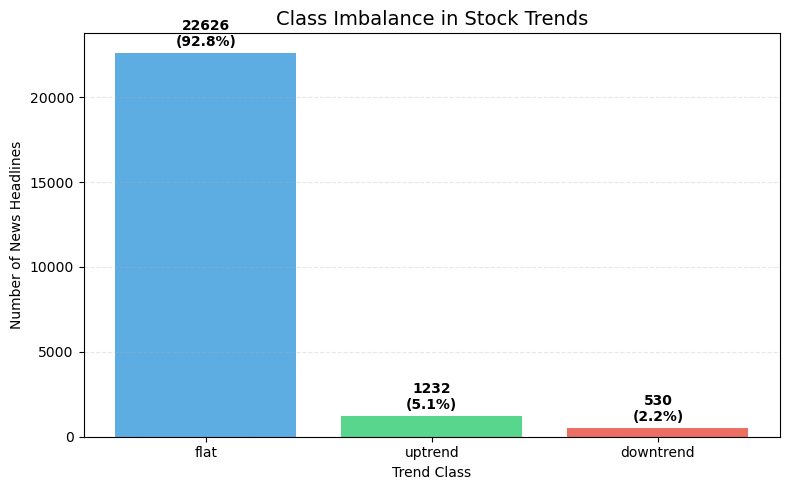

In [56]:
# 1. Get the counts from processed dataframe
trend_counts = df['Trend'].value_counts()
trend_percentages = df['Trend'].value_counts(normalize=True) * 100

# 2. Print the exact numbers
print("=== CLASS IMBALANCE STATISTICS ===")
print(trend_counts)
print("\n=== PERCENTAGES ===")
print(trend_percentages.map('{:.2f}%'.format))

# 3. Create the Visualization
plt.figure(figsize=(8, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c'] # Blue, Green, Red

# Create bar chart
bars = plt.bar(trend_counts.index, trend_counts.values, color=colors, alpha=0.8)

# Add text labels on top of each bar
for bar in bars:
    height = bar.get_height()
    percentage = (height / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 200,
             f'{height}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Class Imbalance in Stock Trends', fontsize=14)
plt.ylabel('Number of News Headlines')
plt.xlabel('Trend Class')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()

# Save
plt.savefig('class_imbalance_chart.png', dpi=300)
plt.show()

## 12. Save Prepared Data 

Save the prepared data for use in subsequent parts of the assignment.

In [57]:
# Save the processed dataframe with trend labels
df_processed = df[['Title', 'Time', 'Name', 'Quote', 'Before', 'After', 'Price_Change_Percent', 'Trend']]

# Create DataFrames for each split
train_data = pd.DataFrame({'Title': X_train, 'Trend': y_train, 'Trend_Encoded': y_train_encoded})
val_data = pd.DataFrame({'Title': X_val, 'Trend': y_val, 'Trend_Encoded': y_val_encoded})
test_data = pd.DataFrame({'Title': X_test, 'Trend': y_test, 'Trend_Encoded': y_test_encoded})

print("Prepared datasets ready for model training!")
print(f"\nVariables available for Part 2 and Part 3:")
print(f"  - X_train, y_train, y_train_encoded")
print(f"  - X_val, y_val, y_val_encoded")
print(f"  - X_test, y_test, y_test_encoded")
print(f"  - label_mapping, reverse_mapping")

Prepared datasets ready for model training!

Variables available for Part 2 and Part 3:
  - X_train, y_train, y_train_encoded
  - X_val, y_val, y_val_encoded
  - X_test, y_test, y_test_encoded
  - label_mapping, reverse_mapping
